In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path
import json
import os

def load_latest_results(experiment_root):
    experiment_root = Path(experiment_root)

    # list timestamped runs
    runs = [p for p in experiment_root.iterdir() if p.is_dir()]
    if not runs:
        raise ValueError(f"No runs found in {experiment_root}")

    latest_run = max(runs, key=lambda p: p.name)

    results_path = latest_run / "results" / "results.json"
    config_path = latest_run / "configs" / "config.json"

    with open(results_path) as f:
        results = json.load(f)

    with open(config_path) as f:
        config = json.load(f)

    return {
        "run_path": latest_run,
        "results": results,
        "config": config
    }


In [ ]:
# Load latest
noise_data_json = load_latest_results("experiments/Similarity vs Theta - KRR - TransitionData (Averaged)")

### Plot similarity for different noises
noise_data_json["run_path"].joinpath("")

if "figures" not in os.listdir(noise_data_json["run_path"]):
    os.mkdir(noise_data_json["run_path"].joinpath("figures"))

for k, r in noise_data_json["results"].items():
    plt.figure()
    std = np.array(r["std_similarities"])
    ci = 1.96*std/np.sqrt(len(std))
    plt.errorbar(r["theta_values"], r["mean_similarities"], ci, marker="*")
    plt.vlines(r["theta_ref"], 0, max(r["mean_similarities"]), "r")
    plt.title(k)
    plt.xlabel("Theta")
    plt.ylabel("Similarity +- 95% ci")

    savepath = noise_data_json["run_path"].joinpath("figures").joinpath(k + ".png")

    plt.savefig(savepath)    

### Plot Similarity drop off
plt.figure()
x = []
y = []
std = []

for k, r in noise_data_json["results"].items():
    idx = np.argmin(np.abs(np.array(r["theta_values"]) - r["theta_ref"]))
    x.append(r["noise"])
    y.append(r["mean_similarities"][idx])
    std.append(r["std_similarities"][idx])

ci = [1.96*s/np.sqrt(len(std)) for s in std]

plt.errorbar(x, y, ci, marker="*")
plt.xlabel("noise")
plt.ylabel("Similarity at $\\theta_{ref}$")

savepath = noise_data_json["run_path"].joinpath("figures").joinpath("similarity_at_ref" + ".png")

plt.savefig(savepath)  

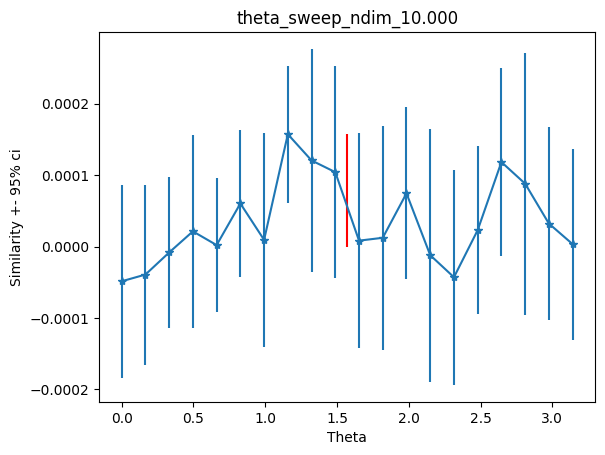

In [ ]:
# Load latest
corr_data_json = load_latest_results("experiments/Similarity vs CorrelatedDims - KRR - TransitionData")

### Plot similarity for different noises
corr_data_json["run_path"].joinpath("")

if "figures" not in os.listdir(corr_data_json["run_path"]):
    os.mkdir(corr_data_json["run_path"].joinpath("figures"))

for k, r in corr_data_json["results"].items():
    plt.figure()
    std = np.array(r["std_similarities"])
    ci = 1.96*std/np.sqrt(len(std))
    plt.errorbar(r["theta_values"], r["mean_similarities"], ci, marker="*")
    plt.vlines(r["theta_ref"], 0, max(r["mean_similarities"]), "r")
    plt.title(k)
    plt.xlabel("Theta")
    plt.ylabel("Similarity +- 95% ci")

    savepath = corr_data_json["run_path"].joinpath("figures").joinpath(k + ".png")

    plt.savefig(savepath)    

### Plot Similarity drop off
plt.figure()
x = []
y = []
std = []

for k, r in corr_data_json["results"].items():
    idx = np.argmin(np.abs(np.array(r["theta_values"]) - r["theta_ref"]))
    x.append(r["n_corr_dim"])
    y.append(r["mean_similarities"][idx])
    std.append(r["std_similarities"][idx])

ci = [1.96*s/np.sqrt(len(std)) for s in std]

plt.errorbar(x, y, ci, marker="*")
plt.xlabel("Number of dimensions")
plt.ylabel("Similarity at $\\theta_{ref}$")

savepath = corr_data_json["run_path"].joinpath("figures").joinpath("similarity_at_ref" + ".png")

plt.savefig(savepath)  

In [ ]:
# Load latest
uncorr_data_json = load_latest_results("experiments/Similarity vs UncorrelatedDims - KRR - TransitionData")

### Plot similarity for different noises
uncorr_data_json["run_path"].joinpath("")

if "figures" not in os.listdir(uncorr_data_json["run_path"]):
    os.mkdir(uncorr_data_json["run_path"].joinpath("figures"))

for k, r in uncorr_data_json["results"].items():
    plt.figure()
    std = np.array(r["std_similarities"])
    ci = 1.96*std/np.sqrt(len(std))
    plt.errorbar(r["theta_values"], r["mean_similarities"], ci, marker="*")
    plt.vlines(r["theta_ref"], 0, max(r["mean_similarities"]), "r")
    plt.title(k)
    plt.xlabel("Theta")
    plt.ylabel("Similarity +- 95% ci")

    savepath = uncorr_data_json["run_path"].joinpath("figures").joinpath(k + ".png")

    plt.savefig(savepath)    

### Plot Similarity drop off
plt.figure()
x = []
y = []
std = []

for k, r in uncorr_data_json["results"].items():
    idx = np.argmin(np.abs(np.array(r["theta_values"]) - r["theta_ref"]))
    x.append(r["n_uncorr_dim"])
    y.append(r["mean_similarities"][idx])
    std.append(r["std_similarities"][idx])

ci = [1.96*s/np.sqrt(len(std)) for s in std]

plt.errorbar(x, y, ci, marker="*")
plt.xlabel("Number of uncorrelated dimensions")
plt.ylabel("Similarity at $\\theta_{ref}$")

savepath = uncorr_data_json["run_path"].joinpath("figures").joinpath("similarity_at_ref" + ".png")

plt.savefig(savepath)  

dict_keys(['theta_sweep_ndim_10.000'])